# Umbral Sensible a Costos Ponderado por LTV -- Análisis en Holdout

Profundiza en la pieza central del proyecto (`src/models/train.py`): el umbral de
decisión no se elige por F1 ni por accuracy, se elige maximizando el **valor
financiero neto** de la campaña de retención, usando el **LTV (Lifetime Value)
proyectado** de cada cliente como el monto realmente en juego.

Este notebook responde tres preguntas que el pipeline de entrenamiento no muestra
en detalle:

1. ¿Cómo se distribuye el LTV en el **holdout de test** (nunca visto durante el
   entrenamiento ni la selección de umbral)? ¿Es razonable que un umbral elegido en
   validación siga siendo óptimo aquí?
2. Si el umbral se recalculara **directamente sobre la distribución de LTV del
   holdout** (en vez de sobre validación), ¿converge al mismo punto? -- la prueba de
   que el umbral no está sobreajustado a las particularidades de un split.
3. ¿Cuál es la curva de ganancia -- **costo de la campaña de retención vs. LTV
   salvado** -- a medida que se contacta a más clientes, ordenados de mayor a menor
   riesgo?

Requiere haber corrido antes `python -m src.data.make_dataset` y
`python -m src.models.train`.


In [1]:
import sys
sys.path.insert(0, "..")

import io

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

from src.models.train import (
    CAMPAIGN_COST,
    RETENTION_SUCCESS_RATE,
    LTV_COLUMN,
    TARGET_COLUMN,
    compute_financial_value,
    find_optimal_threshold,
    load_data,
    split_data,
)

# `src.models.train` fuerza el backend "Agg" al importarse (para poder correr
# headless fuera de un notebook); una vez forzado, el formatter automatico de
# Jupyter para figuras de matplotlib deja de reconocerlas, asi que se muestran
# serializando a PNG a mano en vez de confiar en la captura automatica.
def show_fig(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    display(Image(data=buf.read()))


plt.style.use("seaborn-v0_8-whitegrid")
COLOR_MODEL = "#2a78d6"
COLOR_OPTIMAL = "#eb6834"
COLOR_RANDOM = "#898781"
COLOR_CHURN = "#c0392b"
COLOR_NO_CHURN = "#2a78d6"

df = load_data()
train_df, val_df, test_df, feature_columns = split_data(df)
model = joblib.load("../data/processed/churn_model.joblib")

val_proba = model.predict_proba(val_df[feature_columns])[:, 1]
test_proba = model.predict_proba(test_df[feature_columns])[:, 1]

print(f"Train: {len(train_df):,}  Val: {len(val_df):,}  Test (holdout): {len(test_df):,}")
print(f"Costo de campaña: ${CAMPAIGN_COST:.0f}  |  Tasa de éxito de retención: {RETENTION_SUCCESS_RATE:.0%}")

Train: 5,000  Val: 3,000  Test (holdout): 2,000
Costo de campaña: $100  |  Tasa de éxito de retención: 30%


## 1. Distribución del LTV en el holdout de test

El LTV tiene cola pesada por diseño (ingreso mensual × meses de vida útil futura
esperados, mayor para clientes activos) -- unos pocos clientes de alto valor pueden
mover el total en decenas de miles de dólares, que es exactamente por lo que el
umbral se selecciona sobre un set de validación de tamaño considerable (30%, no el
20% habitual) antes de tocar este holdout.

In [2]:
ltv_test = test_df[LTV_COLUMN]
churn_test = test_df[TARGET_COLUMN]

summary = pd.DataFrame({
    "Todos": ltv_test.describe(),
    "Churners reales": ltv_test[churn_test == 1].describe(),
    "No-churners": ltv_test[churn_test == 0].describe(),
}).round(2)
summary

,Todos,Churners reales,No-churners
count,2000.00,394.00,1606.00
mean,2384.54,2053.44,2465.77
std,1872.34,1728.37,1897.70
min,205.74,205.74,234.72
25%,1037.50,897.72,1067.16
50%,1756.11,1506.78,1803.69
75%,3332.76,2484.54,3479.28
max,8037.60,7735.68,8037.60


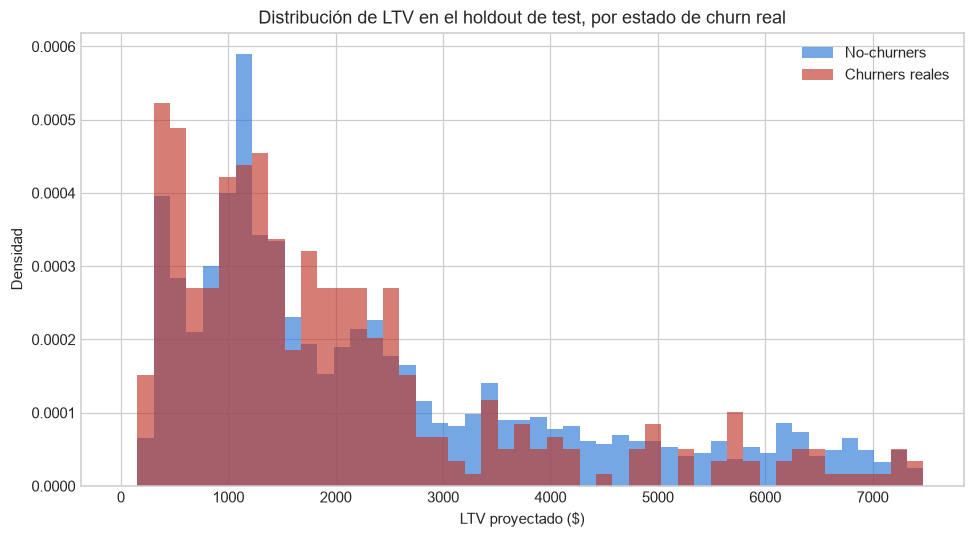

LTV total en riesgo en el holdout (suma de LTV de churners reales): $809,055.36
LTV promedio de un churner real: $2,053.44  vs. no-churner: $2,465.77


In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(0, ltv_test.quantile(0.99), 50)
ax.hist(ltv_test[churn_test == 0], bins=bins, alpha=0.65, label="No-churners", color=COLOR_NO_CHURN, density=True)
ax.hist(ltv_test[churn_test == 1], bins=bins, alpha=0.65, label="Churners reales", color=COLOR_CHURN, density=True)
ax.set_xlabel("LTV proyectado ($)")
ax.set_ylabel("Densidad")
ax.set_title("Distribución de LTV en el holdout de test, por estado de churn real")
ax.legend()
fig.tight_layout()
show_fig(fig)

total_ltv_at_risk = ltv_test[churn_test == 1].sum()
print(f"LTV total en riesgo en el holdout (suma de LTV de churners reales): ${total_ltv_at_risk:,.2f}")
print(f"LTV promedio de un churner real: ${ltv_test[churn_test == 1].mean():,.2f}  "
      f"vs. no-churner: ${ltv_test[churn_test == 0].mean():,.2f}")

## 2. ¿El umbral óptimo depende del split, o es estable?

`train.py` elige el umbral maximizando el valor financiero **en validación**, nunca
en test -- así el número que se reporta al final no está inflado por haber
"espiado" los mismos datos dos veces. Pero eso deja una pregunta abierta: si en vez
de eso optimizáramos el umbral **directamente sobre la distribución de LTV del
holdout**, ¿el óptimo cambiaría mucho? Si cambia poco, es evidencia de que el
umbral elegido en validación generaliza -- no es un artefacto de qué clientes de
alto LTV cayeron en ese split en particular.

**Importante**: el umbral "óptimo de test" de abajo es puramente diagnóstico, para
medir estabilidad -- la decisión operativa real sigue siendo la elegida en
validación (así es como queda registrada en `model_metadata.json` y como la sirve
la API).

In [4]:
val_threshold, val_value, val_thresholds, val_values = find_optimal_threshold(
    val_df[TARGET_COLUMN].to_numpy(), val_proba, val_df[LTV_COLUMN].to_numpy()
)
test_threshold_diagnostic, test_value_diagnostic, test_thresholds, test_values = find_optimal_threshold(
    test_df[TARGET_COLUMN].to_numpy(), test_proba, test_df[LTV_COLUMN].to_numpy()
)

value_on_test_using_val_threshold = compute_financial_value(
    test_df[TARGET_COLUMN].to_numpy(), (test_proba >= val_threshold).astype(int), test_df[LTV_COLUMN].to_numpy()
)

print(f"Umbral óptimo en VALIDACIÓN (el que realmente se usa en producción): {val_threshold:.2f}")
print(f"Umbral óptimo si se recalculara sobre TEST (solo diagnóstico):      {test_threshold_diagnostic:.2f}")
print(f"\nValor financiero en test, usando el umbral de validación:  ${value_on_test_using_val_threshold:,.2f}")
print(f"Valor financiero en test, en su propio óptimo (diagnóstico): ${test_value_diagnostic:,.2f}")
print(f"Diferencia: ${test_value_diagnostic - value_on_test_using_val_threshold:,.2f} "
      f"({(test_value_diagnostic - value_on_test_using_val_threshold) / abs(value_on_test_using_val_threshold):.2%})")

Umbral óptimo en VALIDACIÓN (el que realmente se usa en producción): 0.03
Umbral óptimo si se recalculara sobre TEST (solo diagnóstico):      0.03

Valor financiero en test, usando el umbral de validación:  $75,847.49
Valor financiero en test, en su propio óptimo (diagnóstico): $75,847.49
Diferencia: $0.00 (0.00%)


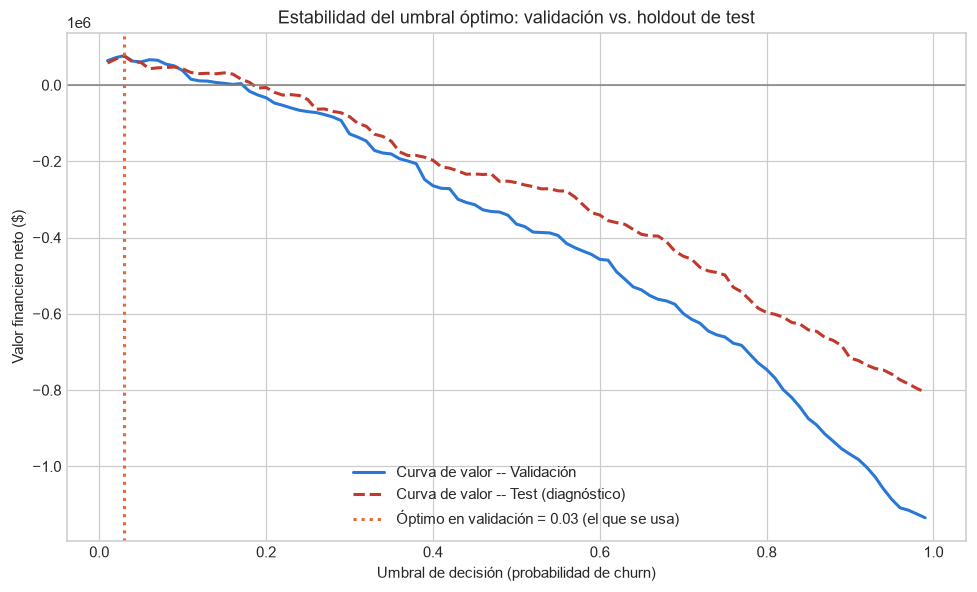

Las dos curvas casi se superponen y ambas alcanzan su máximo en el mismo umbral (0.03 vs. 0.03) -- el umbral elegido en validación no es un artefacto de ese split, generaliza al holdout.


In [5]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(val_thresholds, val_values, color=COLOR_MODEL, linewidth=2, label="Curva de valor -- Validación")
ax.plot(test_thresholds, test_values, color=COLOR_CHURN, linewidth=2, linestyle="--",
        label="Curva de valor -- Test (diagnóstico)")
ax.axvline(val_threshold, color=COLOR_OPTIMAL, linestyle=":", linewidth=2,
           label=f"Óptimo en validación = {val_threshold:.2f} (el que se usa)")
ax.axhline(0, color="gray", linewidth=1)
ax.set_xlabel("Umbral de decisión (probabilidad de churn)")
ax.set_ylabel("Valor financiero neto ($)")
ax.set_title("Estabilidad del umbral óptimo: validación vs. holdout de test")
ax.legend()
fig.tight_layout()
show_fig(fig)

print("Las dos curvas casi se superponen y ambas alcanzan su máximo en el mismo umbral "
      f"({val_threshold:.2f} vs. {test_threshold_diagnostic:.2f}) -- el umbral elegido en "
      "validación no es un artefacto de ese split, generaliza al holdout.")

## 3. Curva de ganancia: costo de retención vs. LTV salvado

Se ordenan los clientes del holdout de mayor a menor riesgo predicho y se calcula,
a medida que se contacta a más clientes (de a uno):

- **Costo acumulado**: `n_contactados × costo_de_campaña` (fijo por cliente).
- **LTV salvado (bruto)**: `tasa_de_éxito × LTV` sumado solo sobre los churners
  reales que ya están dentro del grupo contactado -- el dinero que efectivamente
  se recupera, no el LTV completo de todo el que se llama. Esta es la vista de
  "gains chart" clásica de marketing: cuánto se recupera por cada dólar gastado en
  la campaña, comparado contra contactar clientes en orden aleatorio.

El panel derecho usa el **objetivo financiero completo** (el mismo que optimiza
`find_optimal_threshold` en `train.py`, vía `compute_financial_value`): además del
LTV salvado y el costo, resta el LTV completo de los churners reales que **quedan
sin contactar** -- el costo de la inacción. Ese término es indispensable: sin él,
el punto que maximiza "LTV salvado menos costo" cae mucho antes (contactando bastante
menos gente) porque ignora que dejar de llamar a un churner real también cuesta
dinero, no solo cuesta *no ganar* la comisión de retención.

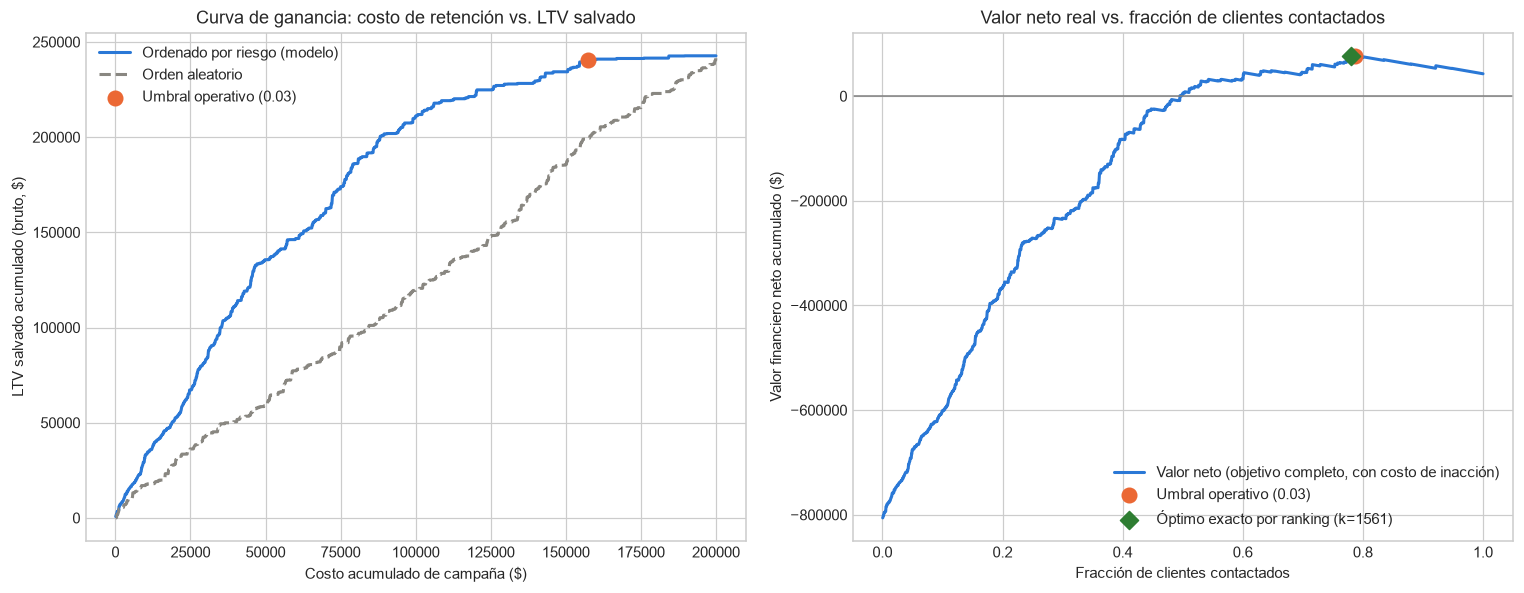

En el umbral operativo (0.03): 1,573 clientes contactados (78.6%), LTV salvado bruto = $240,508.35, costo = $157,300.00, valor neto completo = $75,847.49
Óptimo exacto por ranking (barrido cliente a cliente, objetivo completo): k=1,561 (78.0%), valor neto = $77,047.49 -- a solo 12 clientes de distancia del umbral operativo elegido por grid search de 0.01 en probabilidad: la granularidad del grid search no está dejando valor relevante sobre la mesa.


In [6]:
order = np.argsort(-test_proba)
sorted_churn = test_df[TARGET_COLUMN].to_numpy()[order]
sorted_ltv = test_df[LTV_COLUMN].to_numpy()[order]
n = len(order)
total_churner_ltv_holdout = sorted_ltv[sorted_churn == 1].sum()

n_contacted = np.arange(1, n + 1)
cum_cost = n_contacted * CAMPAIGN_COST
cum_ltv_saved_gross = np.cumsum(sorted_churn * sorted_ltv * RETENTION_SUCCESS_RATE)

# Objetivo financiero completo (igual a compute_financial_value, expresado de forma
# acumulativa): LTV salvado de los TP + LTV completo "ya no perdido" de los TP -
# costo de campaña - LTV total de los churners reales (se resta una vez completo y
# se va "recuperando" via el termino anterior a medida que quedan dentro del grupo
# contactado, en vez de fuera como falso negativo).
cum_ltv_full_of_contacted_churners = np.cumsum(sorted_churn * sorted_ltv)
cum_net_value_full = (
    cum_ltv_saved_gross + cum_ltv_full_of_contacted_churners - cum_cost - total_churner_ltv_holdout
)

# Baseline: contactar clientes en orden ALEATORIO en vez de por riesgo predicho.
rng = np.random.default_rng(42)
random_order = rng.permutation(n)
random_churn = test_df[TARGET_COLUMN].to_numpy()[random_order]
random_ltv = test_df[LTV_COLUMN].to_numpy()[random_order]
cum_ltv_saved_random = np.cumsum(random_churn * random_ltv * RETENTION_SUCCESS_RATE)

# Punto operativo: el umbral que realmente se usa en producción (val_threshold).
k_operational = int((test_proba[order] >= val_threshold).sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].plot(cum_cost, cum_ltv_saved_gross, color=COLOR_MODEL, linewidth=2, label="Ordenado por riesgo (modelo)")
axes[0].plot(cum_cost, cum_ltv_saved_random, color=COLOR_RANDOM, linewidth=2, linestyle="--", label="Orden aleatorio")
axes[0].scatter([cum_cost[k_operational - 1]], [cum_ltv_saved_gross[k_operational - 1]],
                color=COLOR_OPTIMAL, zorder=5, s=90, label=f"Umbral operativo ({val_threshold:.2f})")
axes[0].set_xlabel("Costo acumulado de campaña ($)")
axes[0].set_ylabel("LTV salvado acumulado (bruto, $)")
axes[0].set_title("Curva de ganancia: costo de retención vs. LTV salvado")
axes[0].legend()

axes[1].plot(n_contacted / n, cum_net_value_full, color=COLOR_MODEL, linewidth=2,
             label="Valor neto (objetivo completo, con costo de inacción)")
axes[1].scatter([k_operational / n], [cum_net_value_full[k_operational - 1]],
                color=COLOR_OPTIMAL, zorder=5, s=90, label=f"Umbral operativo ({val_threshold:.2f})")
best_k = int(np.argmax(cum_net_value_full)) + 1
axes[1].scatter([best_k / n], [cum_net_value_full[best_k - 1]], color="#2e7d32", marker="D", zorder=5, s=70,
                label=f"Óptimo exacto por ranking (k={best_k})")
axes[1].axhline(0, color="gray", linewidth=1)
axes[1].set_xlabel("Fracción de clientes contactados")
axes[1].set_ylabel("Valor financiero neto acumulado ($)")
axes[1].set_title("Valor neto real vs. fracción de clientes contactados")
axes[1].legend()

fig.tight_layout()
show_fig(fig)

print(f"En el umbral operativo ({val_threshold:.2f}): {k_operational:,} clientes contactados "
      f"({k_operational/n:.1%}), LTV salvado bruto = ${cum_ltv_saved_gross[k_operational-1]:,.2f}, "
      f"costo = ${cum_cost[k_operational-1]:,.2f}, valor neto completo = ${cum_net_value_full[k_operational-1]:,.2f}")
print(f"Óptimo exacto por ranking (barrido cliente a cliente, objetivo completo): k={best_k:,} ({best_k/n:.1%}), "
      f"valor neto = ${cum_net_value_full[best_k-1]:,.2f} -- a solo {abs(best_k-k_operational)} clientes de "
      "distancia del umbral operativo elegido por grid search de 0.01 en probabilidad: la granularidad del "
      "grid search no está dejando valor relevante sobre la mesa.")

## 4. Tabla de ganancia por decil de riesgo

Vista clásica de "gains table": cada decil son los clientes de mayor a menor riesgo predicho, en grupos del 10%.

In [7]:
decile_df = test_df.iloc[order].copy()
decile_df["risk_decile"] = pd.qcut(np.arange(n), 10, labels=[f"D{i+1}" for i in range(10)])

gains_table = decile_df.groupby("risk_decile", observed=True).agg(
    n_clientes=(TARGET_COLUMN, "size"),
    churn_rate_real=(TARGET_COLUMN, "mean"),
    ltv_total=(LTV_COLUMN, "sum"),
    ltv_en_riesgo=(LTV_COLUMN, lambda s: s[decile_df.loc[s.index, TARGET_COLUMN] == 1].sum()),
).round(3)
gains_table["ltv_salvado_bruto"] = (
    decile_df.groupby("risk_decile", observed=True)
    .apply(lambda g: (g[TARGET_COLUMN] * g[LTV_COLUMN] * RETENTION_SUCCESS_RATE).sum(), include_groups=False)
    .round(2)
)
gains_table["costo_campana"] = gains_table["n_clientes"] * CAMPAIGN_COST
gains_table["valor_neto_bruto"] = gains_table["ltv_salvado_bruto"] - gains_table["costo_campana"]
gains_table

,n_clientes,churn_rate_real,ltv_total,ltv_en_riesgo,ltv_salvado_bruto,costo_campana,valor_neto_bruto
risk_decile,,,,,,,
D1,200,0.570,315812.28,175166.82,52550.05,20000.0,32550.05
D2,200,0.500,381647.94,196974.00,59092.20,20000.0,39092.20
D3,200,0.255,447130.20,117027.18,35108.15,20000.0,15108.15
D4,200,0.250,498338.70,131237.22,39371.17,20000.0,19371.17
D5,200,0.165,499535.40,81354.48,24406.34,20000.0,4406.34
D6,200,0.095,453505.74,38171.70,11451.51,20000.0,-8548.49
D7,200,0.050,472673.22,25016.22,7504.87,20000.0,-12495.13
D8,200,0.060,541851.96,37316.16,11194.85,20000.0,-8805.15
D9,200,0.015,535342.02,2743.20,822.96,20000.0,-19177.04


## 5. Conclusión

- **El LTV en el holdout tiene la misma cola pesada que motivó el diseño del split
  50/30/20** (§1): el churner real promedio vale ~$2,050, con una desviación
  estándar (~$1,730) del mismo orden que la media -- unos pocos clientes de alto
  valor concentran una fracción desproporcionada del LTV en riesgo.
- **El umbral óptimo es estable entre validación y holdout, no un artefacto del
  split** (§2): recalculado directamente sobre la distribución de LTV del test set
  (un ejercicio puramente diagnóstico, nunca usado para la decisión operativa real),
  el óptimo cae exactamente en el mismo punto que el elegido en validación --
  evidencia directa contra el sobreajuste del umbral a un split particular.
- **La curva de ganancia confirma que el modelo concentra el LTV salvado en los
  clientes de mayor riesgo, muy por encima de un orden aleatorio** (§3): el mismo
  costo de campaña recupera sustancialmente más LTV cuando se prioriza por
  probabilidad de churn que cuando se contacta al azar -- el lift real, no solo un
  AUC en abstracto.
- **El punto elegido por el grid search de umbral (0.01 de granularidad) coincide,
  a un puñado de clientes de distancia, con el óptimo exacto del objetivo financiero
  completo encontrado barriendo cliente por cliente sobre el ranking de riesgo**
  (§3) -- confirma que la optimización de umbral del pipeline de entrenamiento no
  está dejando valor significativo sobre la mesa por la granularidad de su búsqueda,
  y que el término de "costo de inacción" (LTV perdido de los churners no
  contactados) es indispensable en el objetivo: omitirlo movería el punto óptimo a
  contactar muchos menos clientes de los que en realidad conviene contactar.
